In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans



In [1]:
from google.colab import files

uploaded = files.upload()

Saving Online_Retail.csv to Online_Retail.csv


In [9]:
df= pd.read_csv('Online_Retail.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [26]:
df['TotalAmount'] = (
    df['Quantity'] *
    df['UnitPrice']
)
display(df.head(5))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate']
)

/tmp/ipykernel_6586/2473742641.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(


In [13]:
snapshot_date = (
    df['InvoiceDate'].max() +
    pd.Timedelta(days=1)
)

In [14]:
rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x:
        (snapshot_date - x.max()).days,

    'InvoiceNo': 'count',

    'TotalAmount': 'sum'

})

In [40]:
rfm.columns = [

    'Recency',
    'Frequency',
    'Monetary',
    'Cluster'

]

In [35]:
X = rfm[

    ['Recency',
     'Frequency',
     'Monetary']

]

In [17]:
kmeans = KMeans(

    n_clusters=4,
    random_state=42

)

In [18]:
rfm['Cluster'] = (
    kmeans.fit_predict(X)
)

In [19]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,0
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,0
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,0


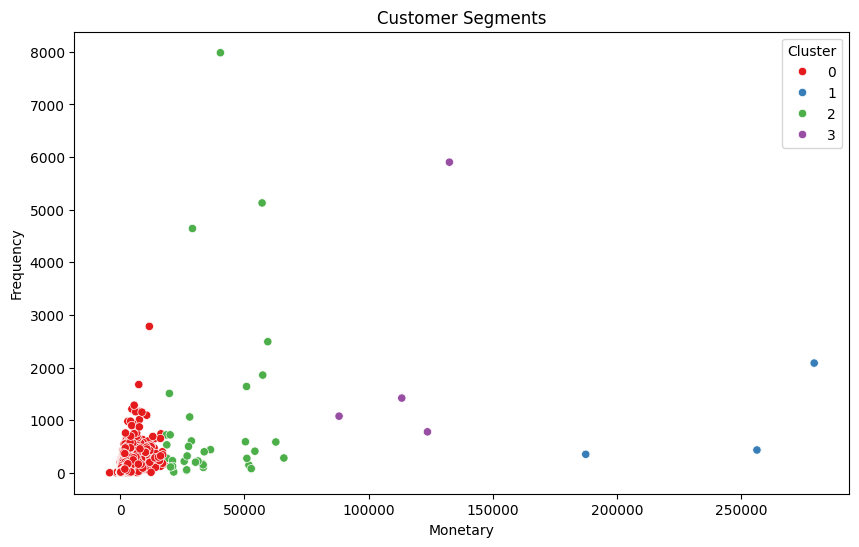

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=rfm,

    x='Monetary',

    y='Frequency',

    hue='Cluster',

    palette='Set1'

)

plt.title(
    'Customer Segments'
)

plt.show()

In [21]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,92.840841,83.148302,1347.622983
1,3.666667,956.333333,241136.560000
2,13.138889,967.611111,35694.129167
3,9.500000,2294.250000,114451.897500
